[Chapter 7](07_Regression.ipynb) built the linear machinery: the model $y_t = \beta_0 + \sum_i \beta_i x_{i,t} + \varepsilon_t$, least squares, residual diagnostics, and a workshop of predictors made from the time index (trend, dummies, Fourier terms).

Three questions were left open. Which of those predictors should we keep? Once the model is fitted, how do we turn it into a forecast, given that a forecast needs the *future* values of the predictors? And what do we do when the relationship is visibly not a straight line, as with the U-shaped electricity demand of Chapter 7 or a trend whose slope changes halfway through the sample?

This chapter answers the three in that order, and closes with the standing warning about correlation and causation.

# Learning objectives

By the end of this lecture you should be able to

1. choose between competing models with **CV, AIC, AICc, BIC** and adjusted $R^2$, and explain why $p$-values are the wrong tool for this;
2. distinguish **ex-ante**, **ex-post**, and **scenario-based** forecasts, and produce prediction intervals;
3. fit **nonlinear** trends by transformation and by **piecewise linear splines**, and say why extrapolating them is dangerous;
4. explain why a good predictor need not be a cause, and what multicollinearity does (and does not) break.

# Setup

Modules and functions used in this lecture.

| Module | Used for |
|---|---|
| `numpy` | `arange`, `maximum`, `sin`, `cos`, `linalg.inv`, `random.default_rng` |
| `pandas` | `read_csv`, `pivot_table`, `resample`, `PeriodIndex`, `period_range`, `DataFrame` |
| `matplotlib.pyplot` | `subplots`, `plot`, `scatter`, `fill_between` |
| `statsmodels.formula.api` | **`ols`**, and `fit.get_prediction` for forecasts with intervals |
| `statsmodels.api` | `add_constant`, the matrix interface used in the appendix |
| `statsmodels.stats.diagnostic` | `acorr_ljungbox` |
| `statsmodels.graphics.tsaplots` | `plot_acf` |
| `itertools` | `combinations`, for the best-subset search |

This chapter carries on with the data and the models of Chapter 7, so the next three cells rebuild that state: the imports, the three helpers we wrote there, and the fitted models we reuse.

In [ ]:
import itertools

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf

pd.set_option("display.float_format", lambda v: f"{v:,.3f}")
rng = np.random.default_rng(0)     # reproducibility

In [2]:
def run_sequence_plot(y, x=None, title="", xlabel="time", ylabel="value",
                      ax=None, figsize=(9, 3), color="blue", **kwargs):
    "Plot a series against time and return the axes."
    if ax is None:
        _, ax = plt.subplots(figsize=figsize)
    if x is None:
        x = getattr(y, "index", np.arange(len(y)))
    ax.plot(x, y, color=color, lw=1, **kwargs)
    ax.set(title=title, xlabel=xlabel, ylabel=ylabel)
    ax.grid(alpha=0.3)
    return ax


def residual_diagnostics(fit, lags=10, title="", figsize=(11, 6)):
    "Four-panel residual check plus a Ljung-Box test."
    e = pd.Series(np.asarray(fit.resid, dtype=float))

    fig, axes = plt.subplots(2, 2, figsize=figsize)
    fig.suptitle(title or "residual diagnostics")

    run_sequence_plot(e.to_numpy(), title="residuals over time", xlabel="observation",
                      ylabel="residual", ax=axes[0, 0])
    axes[0, 0].axhline(0, color="black", lw=0.8)

    plot_acf(e, lags=lags, ax=axes[0, 1], title="ACF of residuals")

    axes[1, 0].hist(e, bins=15, color="blue", alpha=0.7)
    axes[1, 0].set(title="histogram of residuals", xlabel="residual", ylabel="count")
    axes[1, 0].grid(alpha=0.3)

    axes[1, 1].scatter(fit.fittedvalues, e, s=18, color="blue")
    axes[1, 1].axhline(0, color="black", lw=0.8)
    axes[1, 1].set(title="residuals vs fitted", xlabel="fitted value", ylabel="residual")
    axes[1, 1].grid(alpha=0.3)

    fig.tight_layout()

    # Ljung-Box: H0 = residuals are white noise, allowing for the estimated coefficients
    lb = acorr_ljungbox(e, lags=[lags], model_df=int(fit.df_model))
    stat, pval = float(lb["lb_stat"].iloc[0]), float(lb["lb_pvalue"].iloc[0])
    verdict = "no evidence of autocorrelation" if pval > 0.05 else "RESIDUALS ARE AUTOCORRELATED"
    print(f"Ljung-Box (lag {lags}): Q = {stat:.2f}, p = {pval:.4g}  ->  {verdict}")
    return fit


def fourier_terms(t, period, K, prefix="f"):
    "Return a DataFrame of K sine/cosine pairs for the given seasonal period."
    t = np.asarray(t, dtype=float)
    cols = {}
    for k in range(1, K + 1):
        cols[f"{prefix}sin{k}"] = np.sin(2 * np.pi * k * t / period)
        cols[f"{prefix}cos{k}"] = np.cos(2 * np.pi * k * t / period)
    out = pd.DataFrame(cols)
    return out.loc[:, out.std() > 1e-12]        # drop terms that are identically zero

In [3]:
# ---- data (Chapter 7) ----------------------------------------------------------------
raw = pd.read_csv("data/vic_elec.csv")
raw["ds"] = pd.to_datetime(raw["ds"], format="%m/%d/%Y %H:%M")

wide = raw.pivot_table(index="ds", columns="unique_id", values="y")
holiday = raw.loc[raw["unique_id"] == "Demand"].set_index("ds")["Holiday"]

elec = pd.DataFrame({
    "Demand":      wide["Demand"].resample("D").sum() / 1000,   # MW per half hour -> GWh per day
    "Temperature": wide["Temperature"].resample("D").max(),     # daily maximum
})
elec["Holiday"] = holiday.resample("D").max().astype(bool)
elec["Workday"] = (~elec["Holiday"]) & (elec.index.dayofweek < 5)
jan = elec.loc["2014-01"]

beer = pd.read_csv("data/aus_production.csv", parse_dates=["ds"]).set_index("ds")["Beer"]
beer.index = pd.PeriodIndex(beer.index, freq="Q")
beer = beer.loc["1992Q1":"2010Q2"]

beer_df = pd.DataFrame({
    "Beer":    beer.to_numpy(),
    "t":       np.arange(1, len(beer) + 1),
    "quarter": beer.index.quarter,
}, index=beer.index)

harm = fourier_terms(beer_df["t"], period=4, K=2)
harm.index = beer_df.index
beer_fourier = pd.concat([beer_df, harm], axis=1)

austa = pd.read_csv("data/austa.csv")         # Year, Visitors (millions); new in this chapter

# ---- models (Chapter 7) --------------------------------------------------------------
fit_jan     = smf.ols("Demand ~ Temperature", data=jan).fit()
fit_beer    = smf.ols("Beer ~ t + C(quarter)", data=beer_df).fit()
fit_fourier = smf.ols("Beer ~ t + fsin1 + fcos1 + fcos2", data=beer_fourier).fit()

print(f"elec : {len(elec)} days, {elec.index[0].date()} to {elec.index[-1].date()}")
print(f"beer : {len(beer_df)} quarters, R^2 = {fit_beer.rsquared:.3f}")
print(f"austa: {len(austa)} years,    {austa.Year.iloc[0]} to {austa.Year.iloc[-1]}")

elec : 1096 days, 2012-01-01 to 2014-12-31
beer : 74 quarters, R^2 = 0.924
austa: 36 years,    1980 to 2015


# Selecting predictors

Suppose we have several candidate predictors. How do we choose which to keep?

Two popular procedures are **wrong**, and it is worth being explicit about why.

- **Plot $y$ against each predictor and keep the ones that look related.** This misses predictors that only
  matter once another variable is accounted for.
- **Keep the predictors with small $p$-values.** $p$-values test a hypothesis about a coefficient in a
  *particular* model; they do not measure forecasting value, they are distorted by correlated predictors, and
  with enough candidates some will look significant by chance.

Instead, measure **predictive** performance. Let $T$ be the number of observations and $k$ the number of
predictors (excluding the intercept), with $\mathrm{SSE} = \sum e_t^2$.

| Measure | Formula | Choose |
|---|---|---|
| Adjusted $R^2$ | $\bar R^2 = 1 - (1-R^2)\dfrac{T-1}{T-k-1}$ | largest |
| Leave-one-out CV | $\mathrm{CV} = \dfrac{1}{T}\sum_{t=1}^{T}\left[\dfrac{e_t}{1-h_t}\right]^2$ | smallest |
| AIC | $\mathrm{AIC} = T\log\!\left(\dfrac{\mathrm{SSE}}{T}\right) + 2(k+2)$ | smallest |
| AICc | $\mathrm{AICc} = \mathrm{AIC} + \dfrac{2(k+2)(k+3)}{T-k-3}$ | smallest |
| BIC | $\mathrm{BIC} = T\log\!\left(\dfrac{\mathrm{SSE}}{T}\right) + (k+2)\log T$ | smallest |

Notes that matter in practice:

- Each criterion is $T\log(\mathrm{SSE}/T)$ -- fit -- **plus a penalty for complexity**. They differ only in
  how hard they penalize. BIC penalizes hardest ($\log T > 2$ once $T > 7$), so it picks smaller models;
  AICc penalizes more than AIC when $T$ is small, and the two agree as $T$ grows.
- Adjusted $R^2$ is equivalent to minimizing $\hat\sigma_e^2$. It works, but it under-penalizes complexity, so
  **AICc or CV is the better default** for forecasting.
- The LOOCV formula is exact and costs *one* fit: $h_t$ is the $t$-th diagonal of the hat matrix
  $\mathbf{H} = \mathbf{X}(\mathbf{X}^\top\mathbf{X})^{-1}\mathbf{X}^\top$ (Section 7.9). Minimizing CV is
  asymptotically equivalent to minimizing AIC.
- Criteria are comparable only across models fitted to **the same $y$, on the same observations**. Change the
  transformation of $y$ (say, take logs) and the numbers are no longer comparable.

In [4]:
def model_scores(fit, name=None):
    "CV, AIC, AICc, BIC and adjusted R^2, using the textbook definitions."
    T = int(fit.nobs)
    k = int(fit.df_model)                  # predictors, excluding the intercept
    sse = float((fit.resid ** 2).sum())

    aic  = T * np.log(sse / T) + 2 * (k + 2)
    aicc = aic + 2 * (k + 2) * (k + 3) / (T - k - 3)
    bic  = T * np.log(sse / T) + (k + 2) * np.log(T)

    h = fit.get_influence().hat_matrix_diag     # leverages, the diagonal of the hat matrix
    cv = float(np.mean((np.asarray(fit.resid) / (1 - h)) ** 2))

    out = {"k": k, "CV": cv, "AIC": aic, "AICc": aicc, "BIC": bic, "AdjR2": fit.rsquared_adj}
    return {"model": name, **out} if name else out

## Best subset regression on the electricity data

Four candidate blocks of predictors for daily demand in 2014, all of them motivated by the U-shaped scatter:

- **Cooling** $= \max(\text{Temp} - 20,\ 0)$ -- cooling degree days, the right arm of the U;
- **Heating** $= \max(18 - \text{Temp},\ 0)$ -- heating degree days, the left arm;
- **Workday** -- the weekday / non-holiday dummy;
- **Annual Fourier pair** $\sin(2\pi t/365.25),\ \cos(2\pi t/365.25)$ -- whatever seasonal shape is left
  (daylight hours, school terms) after the weather is accounted for.


In [5]:
d14 = elec.loc["2014"].copy()
d14["Cooling"] = np.maximum(d14["Temperature"] - 20, 0)      # cooling degree days
d14["Heating"] = np.maximum(18 - d14["Temperature"], 0)      # heating degree days
d14["Workday"] = d14["Workday"].astype(int)

annual = fourier_terms(d14.index.dayofyear, period=365.25, K=1, prefix="a")
annual.index = d14.index
d14 = pd.concat([d14, annual], axis=1)

d14.head()

,Demand,Temperature,Holiday,Workday,Cooling,Heating,asin1,acos1
ds,,,,,,,,
2014-01-01,175.185,26.000,True,0,6.000,0.000,0.017,1.000
2014-01-02,188.351,23.000,False,1,3.000,0.000,0.034,0.999
2014-01-03,189.086,22.200,False,1,2.200,0.000,0.052,0.999
2014-01-04,173.798,20.300,False,0,0.300,0.000,0.069,0.998
2014-01-05,169.733,26.100,False,0,6.100,0.000,0.086,0.996


In [6]:
blocks = ["Cooling", "Heating", "Workday", "asin1 + acos1"]

rows = []
for r in range(len(blocks) + 1):
    for combo in itertools.combinations(blocks, r):
        formula = "Demand ~ " + (" + ".join(combo) if combo else "1")
        fit = smf.ols(formula, data=d14).fit()
        rows.append(model_scores(fit, name=" + ".join(combo) or "(intercept only)"))

subsets = pd.DataFrame(rows).sort_values("AICc").reset_index(drop=True)
subsets.round(3)

,model,k,CV,AIC,AICc,BIC,AdjR2
0,Cooling + Heating + Workday + asin1 + acos1,5,172.142,"1,874.437","1,874.751","1,901.736",0.765
1,Cooling + Heating + Workday,3,202.955,"1,934.215","1,934.382","1,953.714",0.722
2,Cooling + Workday + asin1 + acos1,4,231.654,"1,983.535","1,983.769","2,006.934",0.683
3,Heating + Workday + asin1 + acos1,4,356.563,"2,148.256","2,148.490","2,171.655",0.502
4,Heating + Workday,2,359.553,"2,151.336","2,151.447","2,166.935",0.495
5,Cooling + Workday,2,382.934,"2,167.428","2,167.539","2,183.027",0.472
6,Workday + asin1 + acos1,3,422.799,"2,209.271","2,209.439","2,228.771",0.410
7,Cooling + Heating + asin1 + acos1,4,444.148,"2,223.368","2,223.603","2,246.767",0.388
8,Workday,1,445.799,"2,228.664","2,228.731","2,240.364",0.374
9,Cooling + Heating,2,474.225,"2,246.770","2,246.881","2,262.370",0.344


All five criteria agree here, which is the comfortable case: the full model wins, and dropping any block makes things clearly worse. Note the ordering of importance, like **Workday** alone buys more than either temperature term, which is the kind of thing a purely weather-driven mental model gets wrong.

Two practical remarks:

1. `statsmodels` reports its own `fit.aic` and `fit.bic`, computed from the full Gaussian log-likelihood and
   counting $k+1$ parameters where the formulas above count $k+2$ (the textbook version treats $\sigma^2$ as
   a parameter too). The gap is the constant $T(1 + \log 2\pi) - 2$, identical for every model fitted to the
   same data, so both conventions rank models the same way. Just never mix them in one table.
2. With 16 models we can enumerate; with 20 candidate predictors there are over a million subsets, and
   stepwise selection is the practical compromise.

In [7]:
best = smf.ols("Demand ~ Cooling + Heating + Workday + asin1 + acos1", data=d14).fit()

T_b, k_b = int(best.nobs), int(best.df_model)
print(f"textbook AIC   = {model_scores(best)['AIC']:.2f}")
print(f"statsmodels AIC= {best.aic:.2f}")
print(f"difference     = {best.aic - model_scores(best)['AIC']:.2f}"
      f"   vs  T(1 + log 2pi) - 2 = {T_b * (1 + np.log(2 * np.pi)) - 2:.2f}")

textbook AIC   = 1874.44
statsmodels AIC= 2908.26
difference     = 1033.83   vs  T(1 + log 2pi) - 2 = 1033.83


Ljung-Box (lag 14): Q = 319.49, p = 1.907e-63  ->  RESIDUALS ARE AUTOCORRELATED


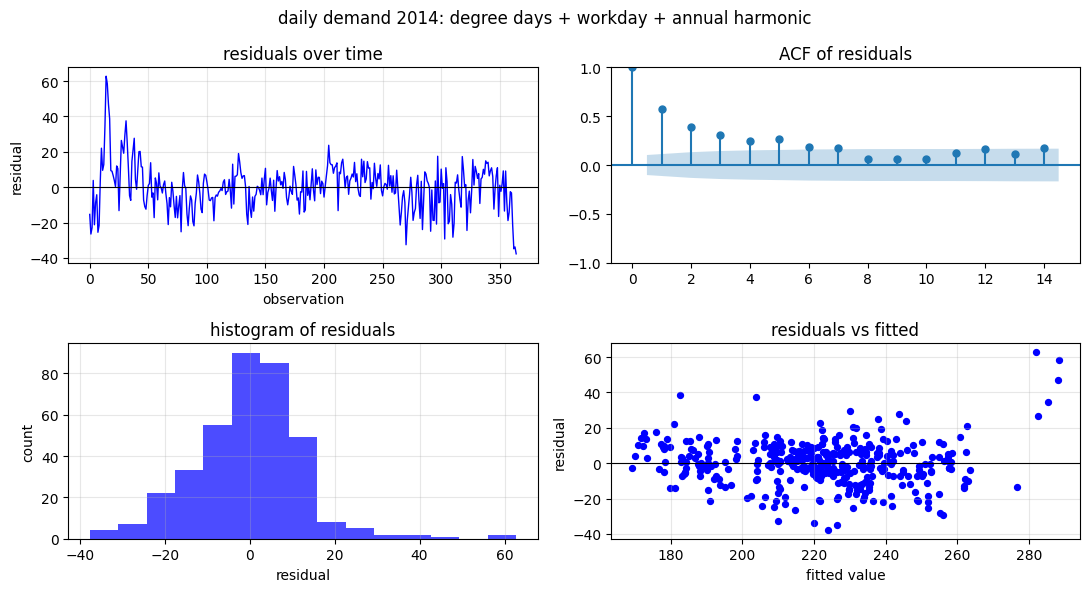

In [8]:
residual_diagnostics(best, lags=14, title="daily demand 2014: degree days + workday + annual harmonic");

Honest reading of this diagnostic: the residual ACF still shows autocorrelation at short lags. Demand today
resembles demand yesterday beyond what temperature and the calendar explain -- humidity, wind, and simple
persistence are missing. The coefficients remain usable, but the prediction intervals from this model will be
too narrow. The repair is to let the *errors* be a time series model themselves (dynamic regression, ARIMA
errors), which is the subject of a later chapter.

# Forecasting with regression

To forecast $y_{T+h}$ we need the predictors at $T+h$. Which predictors we can have determines what kind of
forecast we can make.

| Type | Predictor values used | Honest about uncertainty? |
|---|---|---|
| **Ex-ante** | Only what is known at time $T$ (so future $x$ must itself be forecast, or be deterministic) | Yes -- this is a genuine forecast |
| **Ex-post** | The *observed* future $x$, known only later | No -- useful for judging the model, not for planning |
| **Scenario based** | Values we *assume* ("what if temperature hits 40 C") | Conditional -- intervals ignore the uncertainty in $x$ |

The distinction is not academic. Ex-post forecasts are usually much more accurate than ex-ante ones, and
comparing them separates *model error* from *predictor-forecast error*.

**Deterministic predictors are the lucky case.** Trend, seasonal dummies, Fourier terms and calendar dummies
are all known for any future date, so a trend-plus-season regression gives ex-ante forecasts with no extra
work. That is exactly the beer model.

In [9]:
h = 8
future = pd.period_range(beer_df.index[-1] + 1, periods=h, freq="Q")
beer_future = pd.DataFrame({
    "t":       np.arange(len(beer_df) + 1, len(beer_df) + h + 1),
    "quarter": future.quarter,
}, index=future)

pred = fit_beer.get_prediction(beer_future).summary_frame(alpha=0.05)
pred.index = future
pred[["mean", "mean_ci_lower", "mean_ci_upper", "obs_ci_lower", "obs_ci_upper"]].round(1)

,mean,mean_ci_lower,mean_ci_upper,obs_ci_lower,obs_ci_upper
2010Q3,398.500,390.800,406.100,372.900,424.000
2010Q4,488.700,481.100,496.400,463.200,514.300
2011Q1,415.600,407.900,423.300,390.000,441.200
2011Q2,380.600,372.900,388.300,355.000,406.200
2011Q3,397.100,389.100,405.100,371.400,422.800
2011Q4,487.400,479.400,495.400,461.700,513.100
2012Q1,414.200,406.100,422.300,388.500,439.900
2012Q2,379.200,371.100,387.300,353.500,404.900


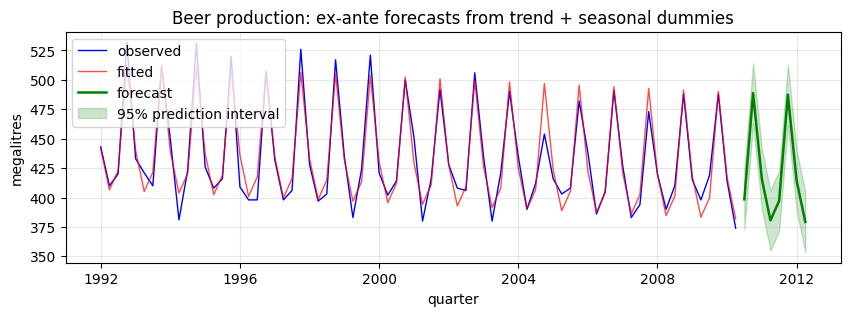

In [10]:
fig, ax = plt.subplots(figsize=(10, 3))
ax.plot(beer_df.index.to_timestamp(), beer_df["Beer"], color="blue", lw=1, label="observed")
ax.plot(beer_df.index.to_timestamp(), fit_beer.fittedvalues, color="red", lw=1, alpha=0.7, label="fitted")

ft = future.to_timestamp()
ax.plot(ft, pred["mean"], color="green", lw=1.8, label="forecast")
ax.fill_between(ft, pred["obs_ci_lower"], pred["obs_ci_upper"], color="green", alpha=0.20,
                label="95% prediction interval")
ax.set(title="Beer production: ex-ante forecasts from trend + seasonal dummies",
       xlabel="quarter", ylabel="megalitres")
ax.legend(); ax.grid(alpha=0.3)

## Prediction intervals

For a simple regression, the forecast $\hat y$ at a new predictor value $x$ has a 95% prediction interval

$$\hat y \pm 1.96\,\hat\sigma_e\sqrt{1 + \frac{1}{T} + \frac{(x - \bar x)^2}{(T-1)s_x^2}},$$

where $s_x$ is the standard deviation of the observed predictor. Three lessons are visible in the formula:

- the **1** inside the root is the irreducible noise. The interval never shrinks to zero, however much data you have;
- the interval **widens as $x$ moves away from $\bar x$**: extrapolation is punished automatically;
- it assumes the errors are normal, uncorrelated and of constant variance. If the residual ACF says otherwise, the interval is too narrow.

`get_prediction` does this for us (with the exact $t$ quantile rather than 1.96); here is the hand computation for a hot 35 C January day, for comparison.

In [11]:
x_new  = 35.0
x_bar  = jan["Temperature"].mean()
s_x    = jan["Temperature"].std(ddof=1)
T_jan  = int(fit_jan.nobs)
sigma  = np.sqrt(fit_jan.scale)

y_hat  = float(fit_jan.params["Intercept"] + fit_jan.params["Temperature"] * x_new)
se_obs = sigma * np.sqrt(1 + 1 / T_jan + (x_new - x_bar) ** 2 / ((T_jan - 1) * s_x ** 2))

print(f"point forecast          : {y_hat:7.1f} GWh")
print(f"by hand      (+/-1.96se): [{y_hat - 1.96 * se_obs:7.1f}, {y_hat + 1.96 * se_obs:7.1f}]")

sm_pi = fit_jan.get_prediction(pd.DataFrame({"Temperature": [x_new]})).summary_frame(alpha=0.05)
print(f"statsmodels  (t quantile): [{sm_pi['obs_ci_lower'].iloc[0]:7.1f}, "
      f"{sm_pi['obs_ci_upper'].iloc[0]:7.1f}]")

point forecast          :   274.5 GWh
by hand      (+/-1.96se): [  224.9,   324.0]
statsmodels  (t quantile): [  222.8,   326.2]


## Scenario-based forecasting

When a predictor is *not* deterministic, e.g., temperature and prices, ex-ante forecasting requires forecasting the predictor too, and the interval should widen accordingly. A common alternative is to be explicit about the assumption instead: **scenarios**.

For a January weekday (`asin1`, `acos1` evaluated at day of year 15), what does the fitted model say about a heatwave day, a mild day, and a cold snap?

In [12]:
doy = 15                                       # mid-January
scenario_temps = [40.0, 30.0, 22.0, 12.0]

scenarios = pd.DataFrame({
    "Temperature": scenario_temps,
    "Cooling": [max(t - 20, 0) for t in scenario_temps],
    "Heating": [max(18 - t, 0) for t in scenario_temps],
    "Workday": 1,
    "asin1": np.sin(2 * np.pi * doy / 365.25),
    "acos1": np.cos(2 * np.pi * doy / 365.25),
}, index=["heatwave 40C", "hot 30C", "mild 22C", "cold snap 12C"])

sf = best.get_prediction(scenarios).summary_frame(alpha=0.05)
sf.index = scenarios.index
out = pd.concat([scenarios[["Temperature"]],
                 sf[["mean", "obs_ci_lower", "obs_ci_upper"]]], axis=1)
out.columns = ["Temperature", "forecast (GWh)", "95% lower", "95% upper"]
out.round(1)

,Temperature,forecast (GWh),95% lower,95% upper
heatwave 40C,40.000,276.600,250.700,302.500
hot 30C,30.000,240.500,215.000,266.000
mild 22C,22.000,211.500,186.000,237.100
cold snap 12C,12.000,241.500,214.900,268.100


These are **conditional** statements: *if* a January weekday reaches 40 C, demand is expected near the value in the first row. The interval reflects the model's residual scatter only. It contains no allowance for the chance that the temperature forecast itself is wrong. That is the price of a scenario, and it should be stated
whenever one is quoted.

# Nonlinear regression

## By transformation

The simplest way to get a nonlinear relationship while keeping least squares is to transform the variables.
With $y$ and/or $x$ in logs:

| Form | Model | Interpretation of $\beta_1$ |
|---|---|---|
| linear-linear | $y = \beta_0 + \beta_1 x$ | unit change in $y$ per unit of $x$ |
| **log-log** | $\log y = \beta_0 + \beta_1 \log x$ | **elasticity**: percent change in $y$ per percent change in $x$ |
| **log-linear** | $\log y = \beta_0 + \beta_1 x$ | roughly $100\beta_1$ percent change in $y$ per unit of $x$ -- *constant growth rate* |
| linear-log | $y = \beta_0 + \beta_1 \log x$ | unit change in $y$ per percent change in $x$ |

Logs require strictly positive data; the usual fix for occasional zeros is $\log(y + 1)$. Remember that a
model fitted to $\log y$ produces forecasts of $\log y$: back-transforming $\exp(\cdot)$ gives the **median**,
not the mean, of the forecast distribution.

The Australian visitors series is the textbook case of a nonlinear trend.

linear     R^2 = 0.9737
log-linear: growth rate = 6.04% per year


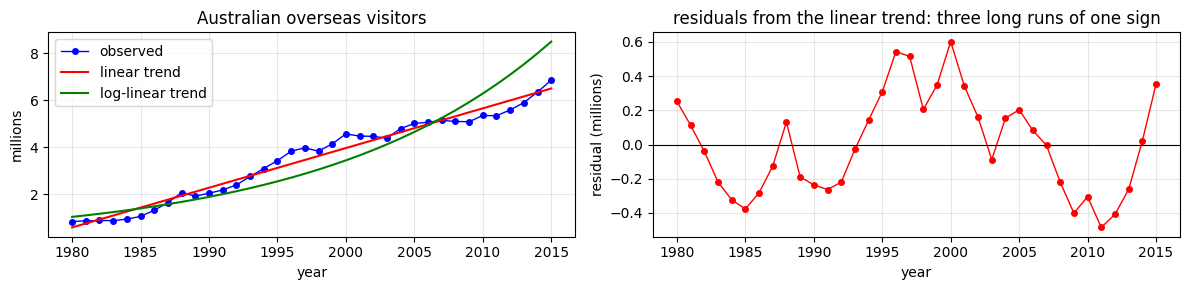

In [13]:
au = austa.copy()
au["t"] = au["Year"] - au["Year"].min()

fit_lin = smf.ols("Visitors ~ t", data=au).fit()
fit_log = smf.ols("np.log(Visitors) ~ t", data=au).fit()

fig, axes = plt.subplots(1, 2, figsize=(12, 3))
axes[0].plot(au["Year"], au["Visitors"], "o-", color="blue", ms=4, lw=1, label="observed")
axes[0].plot(au["Year"], fit_lin.fittedvalues, color="red", lw=1.5, label="linear trend")
axes[0].plot(au["Year"], np.exp(fit_log.fittedvalues), color="green", lw=1.5, label="log-linear trend")
axes[0].set(title="Australian overseas visitors", xlabel="year", ylabel="millions")
axes[0].legend(); axes[0].grid(alpha=0.3)

axes[1].plot(au["Year"], fit_lin.resid, "o-", color="red", ms=4, lw=1, label="linear")
axes[1].axhline(0, color="black", lw=0.8)
axes[1].set(title="residuals from the linear trend: three long runs of one sign",
            xlabel="year", ylabel="residual (millions)")
axes[1].grid(alpha=0.3)
fig.tight_layout()

print(f"linear     R^2 = {fit_lin.rsquared:.4f}")
print(f"log-linear: growth rate = {100 * fit_log.params['t']:.2f}% per year")

The straight line is not terrible ($R^2 \approx 0.97$) and still wrong: the residuals sweep below, then above, then below zero. The constant-growth (log-linear) model overshoots the middle of the sample. What actually happened is a **change of slope**: strong growth to about 2000, a decade of stagnation, then growth again.

## Piecewise linear trends (regression splines)

Instead of one global curve, allow the slope to change at chosen points called **knots**. For a knot at
$\tau$, add the predictor

$$x_{\tau,t} = (t - \tau)_{+} = \max(t - \tau,\ 0),$$

which is $0$ before the knot and rises with slope 1 after it. The model

$$y_t = \beta_0 + \beta_1 t + \beta_2 (t - \tau_1)_{+} + \beta_3 (t - \tau_2)_{+} + \varepsilon_t$$

is **continuous** (no jumps) and **piecewise linear**: the slope is $\beta_1$ before $\tau_1$,
$\beta_1 + \beta_2$ between the knots, and $\beta_1 + \beta_2 + \beta_3$ after $\tau_2$. This is the simplest
regression spline; cubic splines replace the kinks with smooth joins, at the cost of wilder extrapolation.

Knots at 2000 and 2010, chosen from the plot above:

In [14]:
KNOTS = [2000, 2010]

def spline_design(years, knots=KNOTS, origin=austa["Year"].min()):
    "Linear trend plus one (t - knot)+ basis function per knot."
    years = np.asarray(years, dtype=float)
    cols = {"t": years - origin}
    for tau in knots:
        cols[f"k{tau}"] = np.maximum(years - tau, 0.0)
    return pd.DataFrame(cols)

au_spline = pd.concat([au[["Year", "Visitors"]], spline_design(au["Year"])], axis=1)
fit_pw = smf.ols("Visitors ~ t + k2000 + k2010", data=au_spline).fit()

slopes = [fit_pw.params["t"],
          fit_pw.params["t"] + fit_pw.params["k2000"],
          fit_pw.params["t"] + fit_pw.params["k2000"] + fit_pw.params["k2010"]]
for period, s in zip(["1980-2000", "2000-2010", "2010-2015"], slopes):
    print(f"slope {period}: {s:6.3f} million visitors per year")

pd.DataFrame([model_scores(fit_lin, "linear trend"),
              model_scores(fit_pw,  "piecewise linear (knots 2000, 2010)")]).round(3)

slope 1980-2000:  0.201 million visitors per year
slope 2000-2010:  0.093 million visitors per year
slope 2010-2015:  0.274 million visitors per year


,model,k,CV,AIC,AICc,BIC,AdjR2
0,linear trend,1,0.093,-83.280,-82.530,-78.530,0.973
1,"piecewise linear (knots 2000, 2010)",3,0.057,-102.977,-100.977,-95.059,0.985


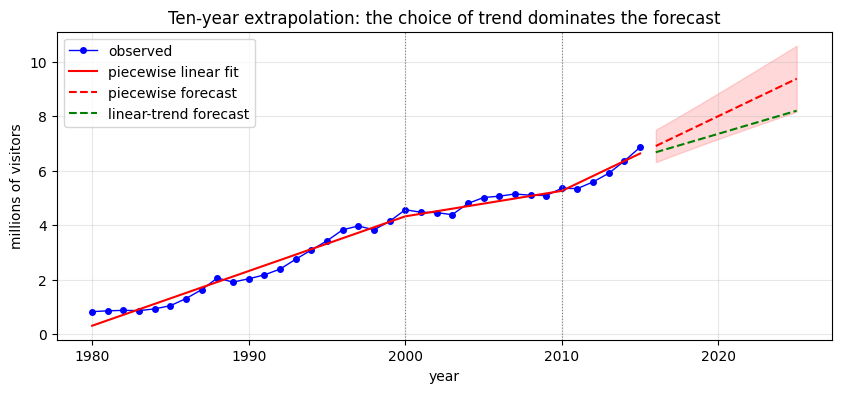

In [15]:
future_years = np.arange(2016, 2026)
fut_design = spline_design(future_years)
pw_fc = fit_pw.get_prediction(fut_design).summary_frame(alpha=0.05)
lin_fc = fit_lin.get_prediction(pd.DataFrame({"t": future_years - austa["Year"].min()})).summary_frame(alpha=0.05)

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(au["Year"], au["Visitors"], "o-", color="blue", ms=4, lw=1, label="observed")
ax.plot(au["Year"], fit_pw.fittedvalues, color="red", lw=1.5, label="piecewise linear fit")
ax.plot(future_years, pw_fc["mean"], color="red", lw=1.5, ls="--", label="piecewise forecast")
ax.fill_between(future_years, pw_fc["obs_ci_lower"], pw_fc["obs_ci_upper"], color="red", alpha=0.15)
ax.plot(future_years, lin_fc["mean"], color="green", lw=1.5, ls="--", label="linear-trend forecast")
for tau in KNOTS:
    ax.axvline(tau, color="grey", lw=0.8, ls=":")
ax.set(title="Ten-year extrapolation: the choice of trend dominates the forecast",
       xlabel="year", ylabel="millions of visitors")
ax.legend(); ax.grid(alpha=0.3)

By 2025 the two trends differ by more than a million visitors a year, and the prediction intervals, built on the assumption that the *fitted* trend continues. Flexible trends fit the past better and extrapolate worse: each extra knot is a slope that is free to be wrong forever. Keep the knots few, place them where the mechanism changed (a recession, a regulation, a new runway), and distrust long horizons.

# Correlation, causation and forecasting

**Correlation is not causation**, less often said, **causation is not required for forecasting**. A model built on a **confounder** can forecast perfectly well, right up to the moment the confounding relationship changes; what it must never do is justify an intervention.

Three habits follow:

- Say plainly whether you are building a model to **forecast** or to **explain**. They are judged differently;
  a forecasting model needs predictive accuracy, an explanatory model needs identification.
- Watch for **reversed causality**: a hotel adds rooms because demand is rising, so rooms predict demand
  without causing it.
- Remember that forecasting with a *causal* predictor still requires forecasting that predictor, which may be
  harder than the original problem.

## Multicollinearity

Two or more predictors that are highly correlated carry nearly the same information, and least squares cannot
tell their contributions apart. Watch what happens if we add temperature **in Fahrenheit** to a model that
already has it in Celsius (with a whisper of noise so the matrix is not exactly singular).

In [16]:
collinear = jan.copy()
noise = np.random.default_rng(1).normal(scale=0.05, size=len(collinear))   # own seed: the point should not
collinear["TempF"] = collinear["Temperature"] * 9 / 5 + 32 + noise            # depend on what ran before

fit_mc = smf.ols("Demand ~ Temperature + TempF", data=collinear).fit()

compare = pd.DataFrame({
    "coefficient": [fit_jan.params["Temperature"], np.nan, fit_jan.rsquared],
    "collinear":   [fit_mc.params["Temperature"], fit_mc.params["TempF"], fit_mc.rsquared],
}, index=["Temperature", "TempF", "R^2"])
print(compare.round(3), "\n")
print("standard errors in the collinear model:")
print(fit_mc.bse.round(2))
print(f"\ncorrelation(Temperature, TempF) = {collinear['Temperature'].corr(collinear['TempF']):.6f}")

             coefficient  collinear
Temperature        6.154   -139.518
TempF                NaN     80.904
R^2                0.783      0.788 

standard errors in the collinear model:
Intercept     3,160.480
Temperature     177.920
TempF            98.810
dtype: float64

correlation(Temperature, TempF) = 0.999994


The fit ($R^2$) barely moves, but the individual coefficients explode to large values of opposite sign with
enormous standard errors -- and they would swing wildly if we refitted on a slightly different sample. That is
the whole story of multicollinearity:

- **Broken:** interpreting individual coefficients, testing them, and any forecast that requires extrapolating
  the predictors *outside the pattern of correlation seen in the data*.
- **Not broken:** the fitted values, and forecasts made where the predictors keep their historical
  relationship. For pure forecasting, multicollinearity is often tolerable.

Diagnose it by looking at the correlation matrix of the predictors, at variance inflation factors, or at
coefficients that change sign when a variable is added. Fix it by dropping redundant predictors, combining
them, or using a penalized method (ridge, lasso).

# Appendix: Matrix formulation

Stack the observations. With $\mathbf{y} = (y_1,\dots,y_T)^\top$, $\boldsymbol\beta = (\beta_0,\dots,\beta_k)^\top$,
$\boldsymbol\varepsilon = (\varepsilon_1,\dots,\varepsilon_T)^\top$, and

$$\mathbf{X} = \begin{bmatrix}
1 & x_{1,1} & \cdots & x_{k,1}\\
1 & x_{1,2} & \cdots & x_{k,2}\\
\vdots & \vdots & & \vdots\\
1 & x_{1,T} & \cdots & x_{k,T}
\end{bmatrix},
\qquad
\mathbf{y} = \mathbf{X}\boldsymbol\beta + \boldsymbol\varepsilon .$$

Minimizing $(\mathbf{y}-\mathbf{X}\boldsymbol\beta)^\top(\mathbf{y}-\mathbf{X}\boldsymbol\beta)$ gives

$$\hat{\boldsymbol\beta} = (\mathbf{X}^\top\mathbf{X})^{-1}\mathbf{X}^\top\mathbf{y},
\qquad
\hat{\mathbf{y}} = \mathbf{X}\hat{\boldsymbol\beta} = \mathbf{H}\mathbf{y},
\qquad
\mathbf{H} = \mathbf{X}(\mathbf{X}^\top\mathbf{X})^{-1}\mathbf{X}^\top,$$

where $\mathbf{H}$ is the **hat matrix** (it puts the hat on $\mathbf{y}$). Its diagonal entries $h_t$ are the
**leverages** -- how much observation $t$ pulls its own fitted value -- and they are what make the one-fit
LOOCV formula of Section 7.5 work:

$$e_{(t)} = \frac{e_t}{1 - h_t},$$

the error you would have made at $t$ had you fitted the model without observation $t$. The forecast at a new
row $\mathbf{x}^*$ is $\hat y = \mathbf{x}^{*\top}\hat{\boldsymbol\beta}$ with variance
$\hat\sigma_e^2\bigl[1 + \mathbf{x}^{*\top}(\mathbf{X}^\top\mathbf{X})^{-1}\mathbf{x}^*\bigr]$, the general form
of the prediction-interval formula in Section 7.6.

In [17]:
Xb = sm.add_constant(beer_fourier[["t", "fsin1", "fcos1", "fcos2"]].to_numpy())
yb = beer_fourier["Beer"].to_numpy()

XtX_inv = np.linalg.inv(Xb.T @ Xb)
beta_m  = XtX_inv @ Xb.T @ yb
H       = Xb @ XtX_inv @ Xb.T
h_diag  = np.diag(H)

resid_m = yb - Xb @ beta_m
cv_manual = np.mean((resid_m / (1 - h_diag)) ** 2)

print("beta (matrix)      :", np.round(beta_m, 4))
print("beta (statsmodels) :", np.round(fit_fourier.params.to_numpy(), 4))
print(f"\nleverage: mean = {h_diag.mean():.4f}  (equals (k+1)/T = {Xb.shape[1] / len(yb):.4f}), "
      f"max = {h_diag.max():.4f}")
print(f"LOOCV by hand      = {cv_manual:.4f}")
print(f"LOOCV from helper  = {model_scores(fit_fourier)['CV']:.4f}")

beta (matrix)      : [ 4.468792e+02 -3.403000e-01  8.910800e+00  5.372810e+01  1.398960e+01]
beta (statsmodels) : [ 4.468792e+02 -3.403000e-01  8.910800e+00  5.372810e+01  1.398960e+01]

leverage: mean = 0.0676  (equals (k+1)/T = 0.0676), max = 0.0910
LOOCV by hand      = 160.0944
LOOCV from helper  = 160.0944


# Summary

| Idea | Practical form |
|---|---|
| Model choice | Minimize **AICc** or **CV** (or BIC for a smaller model); never select on $p$-values |
| The criteria | All are $T\log(\mathrm{SSE}/T)$ plus a penalty for $k$; comparable only across models for the same $y$ |
| Forecasting | Ex-ante needs future predictors; ex-post is for evaluation; scenarios are conditional statements |
| Intervals | $\hat y \pm 1.96\hat\sigma_e\sqrt{1 + 1/T + (x-\bar x)^2/((T-1)s_x^2)}$, widens away from $\bar x$, too narrow if the residuals are autocorrelated |
| Nonlinearity | Logs for elasticities and constant growth; $(t-\tau)_+$ knots for slope changes; extrapolate cautiously |
| Causation | A useful predictor need not be a cause; multicollinearity wrecks coefficients, not necessarily forecasts |
| Matrix form | $\hat{\boldsymbol\beta} = (\mathbf{X}^\top\mathbf{X})^{-1}\mathbf{X}^\top\mathbf{y}$, $\mathbf{H} = \mathbf{X}(\mathbf{X}^\top\mathbf{X})^{-1}\mathbf{X}^\top$, leverages $h_t$ give one-fit LOOCV |

**What is still missing.** The best model here still left autocorrelation in its residuals, and nothing in this chapter repairs that. Letting the error term be an ARIMA process, i.e., *dynamic regression*, is where the course goes next.